# TINYViT assesment:

Multiple ViT profiles were made in `/config/vit_configs.json`, we trained them in notebook `3.5`, now we evaluate all of those configurations over the unseen validationdata (the 10% part that was taken away in notebook `3.1`). 

The best performing configuration out of this assesment gets trained on the full dataset, without making further changes to the configuration. There is a certain methodological risk involved to go from four to thirty classes. But this effect was hardly seen on using TINYCNN vs the full CNN training (`3.2` vs `3.3`). So I'm fairly optimistic

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

import sys
sys.path.append('../../utils')
from vit_helpers import ImageDataGeneratorFromDF, PatchEncoder, Patches, get_vit_configurations

from configloader import Configloader

import cnn_helpers
import implot


2025-04-15 22:47:49.316652: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
PHASE = 'brand phase'
CROP = True
BATCH_SIZE = 128
SHAPE = 224


TESTMODE = True


In [3]:
cnn_helpers.system_override()
cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-04-15 22:47:51.435296: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-15 22:47:53.787010: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-15 22:47:53.787094: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


'GPU'

In [4]:
config = Configloader()

vit_variants = get_vit_configurations(
    os.path.join(
        config.get('directories', 'root_dir'), 
        config.get('settings', 'vit_configurations')
    )
)

In [5]:

basedir = config.get('settings', 'image_directory')
csv_data_dir = config.get('dir_augmentations', 'csv_dir')



In [6]:
csv_dir = os.path.join(basedir, csv_data_dir, PHASE)  #where the train/test/valid split in step 3.1 was done.
csv_dir

'/home/frederic/Documents/automotive_image_data/CSV-data/brand phase'

In [7]:
validation_df_path = os.path.join(csv_dir, 'validationdata_brandphase.csv')
validation_df = pd.read_csv(validation_df_path)

In [8]:
# Testmode - reduce brands
if 'TESTMODE' in locals() and  TESTMODE:
    brands = ['ford', 'opel', 'bmw', 'renault']
    validation_df = validation_df[validation_df['brand'].isin(brands)]


In [9]:
brands = validation_df.brand.unique()
label_encoder = LabelEncoder()
label_encoder.fit(brands)
validation_df['y_encoded'] = label_encoder.transform(validation_df['brand'])


In [10]:
validation_df = cnn_helpers.shuffle_df(validation_df)
validation_df

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,brand,abs_path,y_encoded
0,10247518,left,0.999999,118,144,656,385,10247518,0.986005,0.733450,0.655542,0.979159,opel,/home/frederic/Documents/automotive_image_data...,2
1,9136912,rearleft,0.937837,4,128,732,445,9136912,0.987072,0.999970,0.934360,0.997946,bmw,/home/frederic/Documents/automotive_image_data...,0
2,7535521,frontleft,1.000000,36,55,689,490,7535521,0.986504,1.000000,0.997969,0.990088,opel,/home/frederic/Documents/automotive_image_data...,2
3,1443278,frontright,1.000000,24,192,710,540,1443278,0.947283,0.984731,0.772473,0.220166,bmw,/home/frederic/Documents/automotive_image_data...,0
4,7003561,left,1.000000,16,106,666,381,7003561,0.994899,0.998456,0.789985,0.984668,renault,/home/frederic/Documents/automotive_image_data...,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110599,7532113,rearleft,0.999998,77,69,644,439,7532113,0.876584,0.999741,0.970687,0.994803,opel,/home/frederic/Documents/automotive_image_data...,2
110600,1546055,left,1.000000,43,155,704,420,1546055,0.999955,0.999976,0.986554,0.997832,bmw,/home/frederic/Documents/automotive_image_data...,0
110601,5162503,frontright,1.000000,2,84,741,526,5162503,0.949058,0.975261,0.442779,0.910105,ford,/home/frederic/Documents/automotive_image_data...,1
110602,14686276,right,0.640912,76,127,691,430,14686276,0.705051,0.983414,0.655024,0.957727,opel,/home/frederic/Documents/automotive_image_data...,2


In [11]:


model_read_dir = os.path.join(config.get('directories', 'root_dir'),
                              config.get('directories', 'vit_dir'))


In [12]:
# Training was done on the front angle only, do'nt bother 

all_vit_results = {}
angles = ['front']

# Run evaluation loop on all ids in the dict
for vit_id, variant in vit_variants.items():
    patch_size = variant["PATCH_SIZE"]
    shape = variant["SHAPE"]
    PATCHES = (shape // patch_size) ** 2
    print(f"Evaluating ViT: {vit_id} with PATCH_SIZE={patch_size}, PATCHES={PATCHES}")

    for angle in angles:
        name = f'{vit_id}-model_cropped={CROP}_angle={angle}.keras'
        model_path = os.path.join(model_read_dir, name)
        if not os.path.exists(model_path):
            print(f"Model {name} not found, skipping.")
            continue

        print(f"→ Loading model {name}...")
        model = keras.models.load_model(model_path,
                                        custom_objects={"Patches": Patches,
                                                        "PatchEncoder": PatchEncoder})

        view_by_angle_test = validation_df.query('model_label==@angle').reset_index()
        generator = ImageDataGeneratorFromDF(
            df=view_by_angle_test,
            image_column='abs_path',
            label_column='y_encoded',
            batch_size=BATCH_SIZE,
            target_size=(shape, shape),
            shuffle=False,
            apply_crop=CROP
        )

        predictions = []
        #annoyin caveat of Keras, it requires all batches to be of equal length; 
        # this is a way around the issue without the risk of accidentally padding
        # the final batch with a underrepresented test class. (adding 3 entries of a 
        # class that only occurs 4 times naturally)
        for x_batch, y_batch in generator:
            if len(x_batch)  == 0:
                break
            batch_preds = model.predict_on_batch(x_batch)
            predictions.extend(batch_preds)
        all_vit_results[vit_id] = predictions


Evaluating ViT: ViT1 with PATCH_SIZE=28, PATCHES=64
→ Loading model ViT1-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
2025-04-15 22:47:54.629065: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-15 22:47:54.629308: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-15 22:47:54.629404: I external/local_xla/xla/stream_executor/rocm/rocm_executor

Evaluating ViT: ViT2 with PATCH_SIZE=28, PATCHES=64
→ Loading model ViT2-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Evaluating ViT: ViT3 with PATCH_SIZE=16, PATCHES=196
→ Loading model ViT3-model_cropped=True_angle=front.keras...


...

/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Evaluating ViT: ViT15 with PATCH_SIZE=22, PATCHES=100
→ Loading model ViT15-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Evaluating ViT: ViT16 with PATCH_SIZE=22, PATCHES=100
→ Loading model ViT16-model_cropped=True_angle=front.keras...


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/keras/src/layers/layer.py:396: UserWarning: `build()` was called on layer 'patch_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


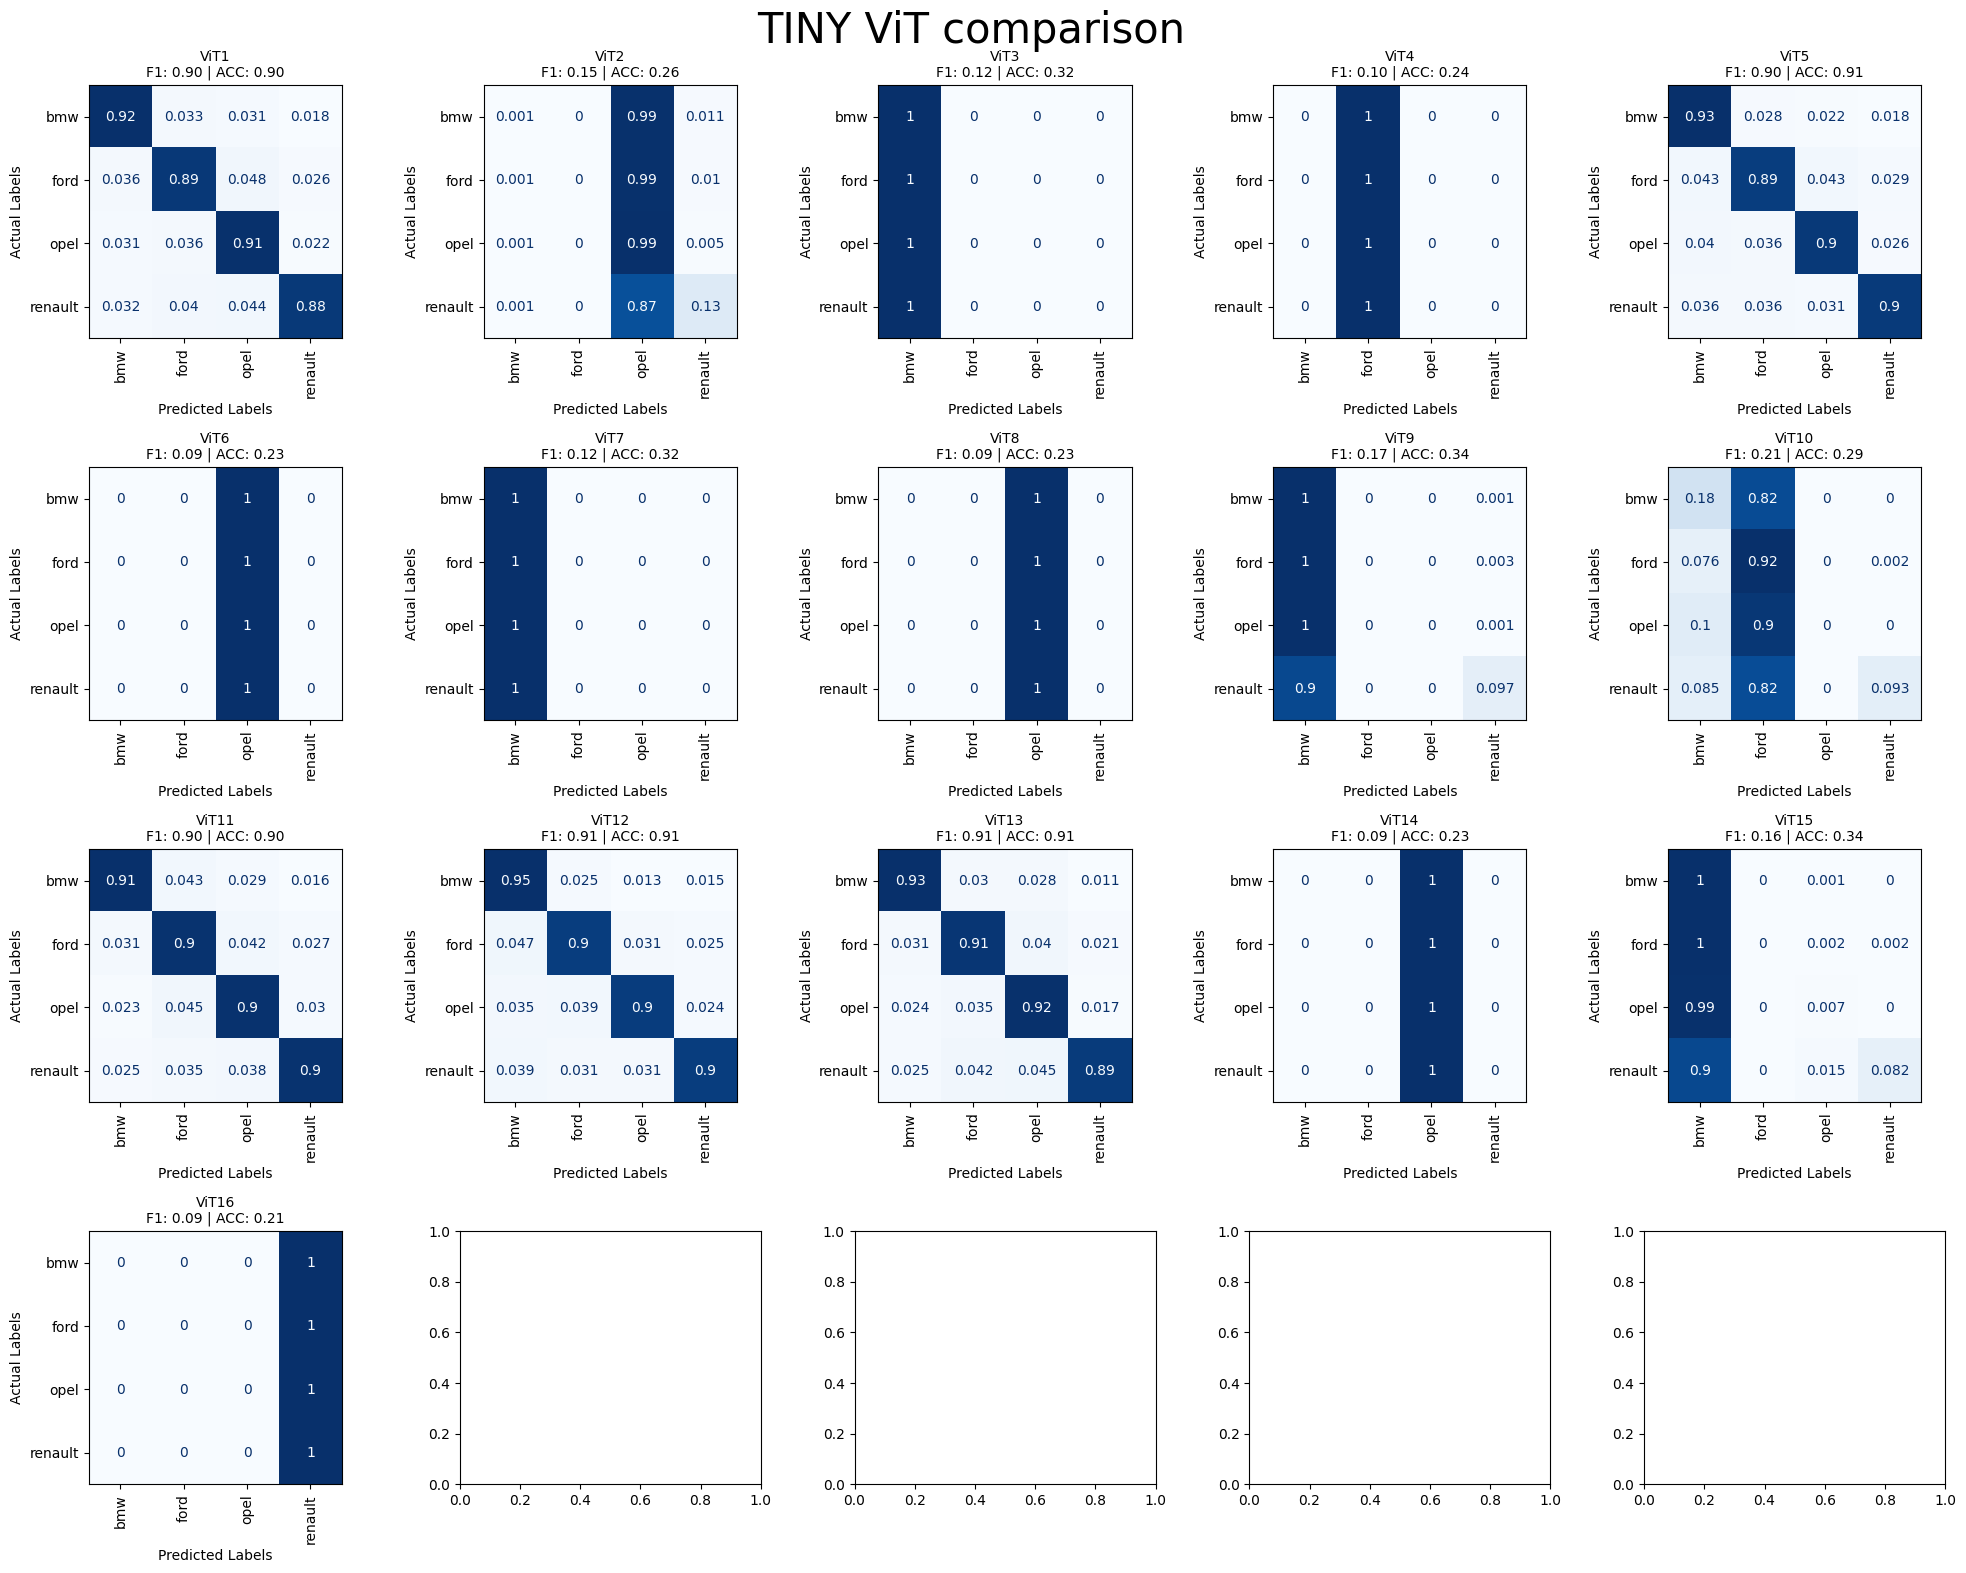

In [17]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))  # Adjust size as needed
axes = axes.flatten()  # Flatten to iterate easily

actual_labels = view_by_angle_test.y_encoded

for i, (vitname, predictions) in enumerate(all_vit_results.items()):
    if i >= 20:
        break

    prediction_labels = np.argmax(predictions, axis=1)
    metrics = implot.quick_metrics(actual_labels, prediction_labels)

    disp = implot.make_cm(actual_labels, prediction_labels, label_encoder.classes_, embed=True)
    ax = axes[i]
    disp.plot(ax=ax, cmap='Blues', colorbar=False)

    ax.set_title(f'{vitname}\nF1: {metrics["Macro F1 Score"]:.2f} | ACC: {metrics["Accuracy"]:.2f}', fontsize=10)
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("Actual Labels")
    ax.tick_params(axis='x', rotation=90)


plt.suptitle('TINY ViT comparison', fontsize=30)
plt.tight_layout()
plt.show()